In [2]:
pip install netCDF4 numpy pandas matplotlib scipy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.4 MB/s eta 0:00:00


In [3]:
import netCDF4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess
import datetime

In [6]:
ds = netCDF4.Dataset("2020_31TCG_patch_14_04.nc")

print(ds)
print(ds.groups.keys())

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    title: S4A Patch Dataset
    authors: Papoutsis I., Sykas D., Zografakis D., Sdraka M.
    patch_full_name: 2020_31TCG_patch_14_04
    patch_year: 2020
    patch_name: patch_14_04
    patch_country_code: ES
    patch_tile: 31TCG
    creation_date: 27 Apr 2021
    references: Documentation available at .
    institution: National Observatory of Athens.
    version: 21.03
    _format: NETCDF4
    _nco_version: netCDF Operators version 4.9.1 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)
    _xarray_version: 0.17.0
    dimensions(sizes): 
    variables(dimensions): 
    groups: B01, B02, B03, B04, B05, B06, B07, B08, B09, B10, B11, B12, B8A, labels, parcels
dict_keys(['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A', 'labels', 'parcels'])


In [7]:
nir = ds["B08"]["B08"][:] / 10000
red = ds["B04"]["B04"][:] / 10000
rededge = ds["B05"]["B05"][:] / 10000
blue = ds["B02"]["B02"][:] / 10000

In [8]:
rededge = rededge.repeat(2, axis=1).repeat(2, axis=2)

In [9]:
ndvi = (nir - red) / (nir + red)

ndre = (nir - rededge) / (nir + rededge)

evi = 2.5 * ((nir - red) / (nir + 6*red - 7.5*blue + 1))

cire = (nir / rededge) - 1

In [10]:
parcels = ds["parcels"]["parcels"][:]

parcel_ids = np.unique(parcels)
parcel_ids = parcel_ids[parcel_ids != 0]

print("Total fields:", len(parcel_ids))

Total fields: 5


In [11]:
time_var = ds["B08"]["time"]
dates = netCDF4.num2date(time_var[:], time_var.units)

dates_py = [
    datetime.datetime(d.year, d.month, d.day, d.hour, d.minute, d.second)
    for d in dates
]

In [12]:
pid = parcel_ids[0]

mask = parcels == pid

ndvi_series = np.nanmean(np.where(mask, ndvi, np.nan), axis=(1,2))
ndre_series = np.nanmean(np.where(mask, ndre, np.nan), axis=(1,2))
evi_series = np.nanmean(np.where(mask, evi, np.nan), axis=(1,2))
cire_series = np.nanmean(np.where(mask, cire, np.nan), axis=(1,2))

In [13]:
df = pd.DataFrame({
    "date": dates_py,
    "NDVI": ndvi_series,
    "NDRE": ndre_series,
    "EVI": evi_series,
    "CIre": cire_series
})

df = df.sort_values("date")

In [14]:
df = df.set_index("date")

df_resampled = df.resample("10D").mean()

df_resampled = df_resampled.interpolate()

In [15]:
ndvi = df_resampled["NDVI"].values
ndre = df_resampled["NDRE"].values
evi = df_resampled["EVI"].values
cire = df_resampled["CIre"].values

In [16]:
ndvi_smooth = savgol_filter(ndvi, 7, 2)
ndre_smooth = gaussian_filter1d(ndre, sigma=2)
lowess_result = lowess(evi, np.arange(len(evi)), frac=0.2)

evi_smooth = lowess_result[:,1]
window = 5

cire_smooth = np.convolve(cire, np.ones(window)/window, mode="same")

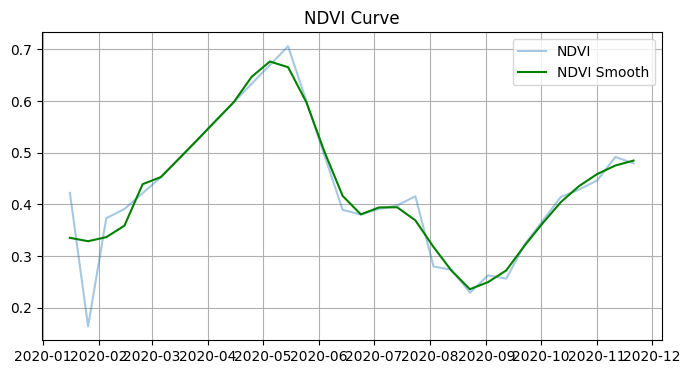

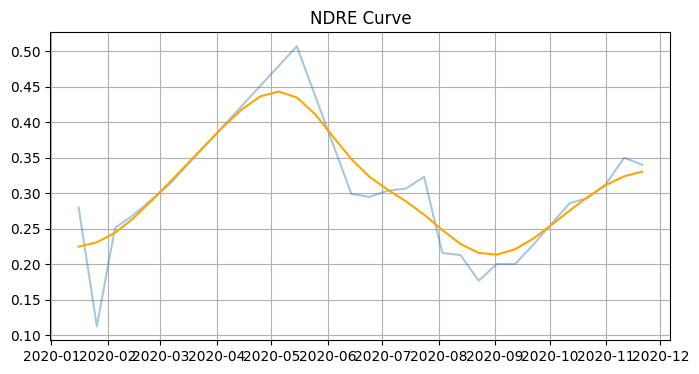

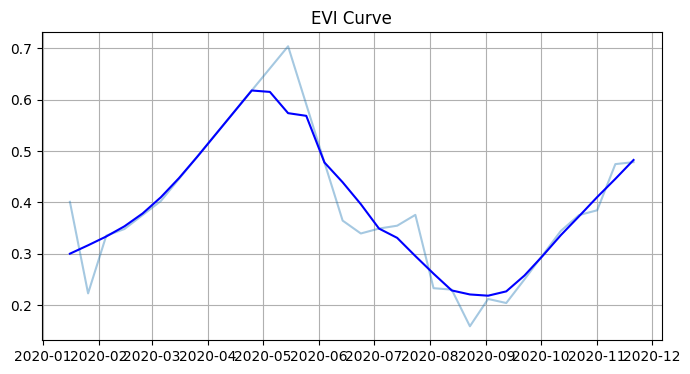

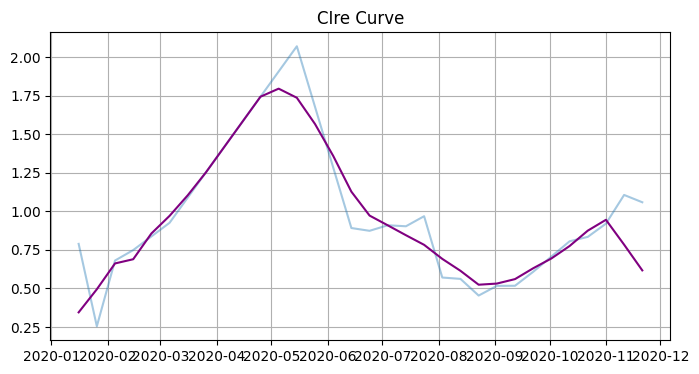

In [17]:
plt.figure(figsize=(8,4))

plt.plot(df_resampled.index, ndvi, label="NDVI", alpha=0.4)

plt.plot(df_resampled.index, ndvi_smooth, label="NDVI Smooth", color="green")

plt.title("NDVI Curve")

plt.legend()

plt.grid()

plt.show()

plt.figure(figsize=(8,4))

plt.plot(df_resampled.index, ndre, alpha=0.4)

plt.plot(df_resampled.index, ndre_smooth, color="orange")

plt.title("NDRE Curve")

plt.grid()

plt.show()


plt.figure(figsize=(8,4))

plt.plot(df_resampled.index, evi, alpha=0.4)

plt.plot(df_resampled.index, evi_smooth, color="blue")

plt.title("EVI Curve")

plt.grid()

plt.show()

plt.figure(figsize=(8,4))

plt.plot(df_resampled.index, cire, alpha=0.4)

plt.plot(df_resampled.index, cire_smooth, color="purple")

plt.title("CIre Curve")

plt.grid()

plt.show()


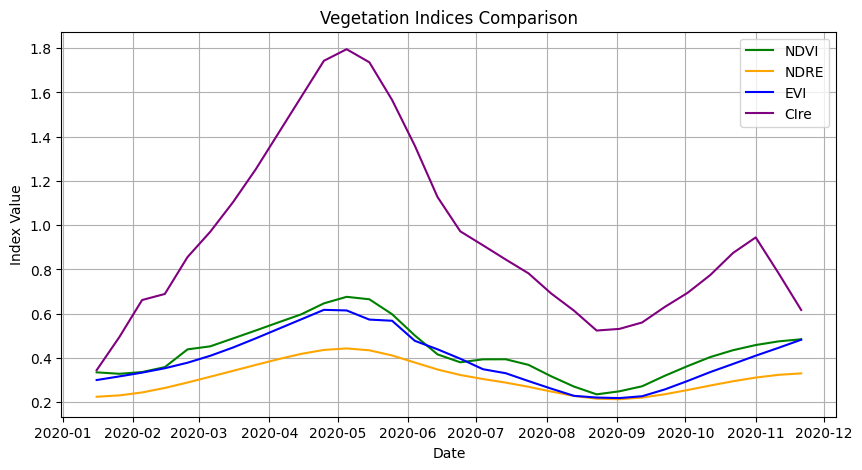

In [18]:
plt.figure(figsize=(10,5))

plt.plot(df_resampled.index, ndvi_smooth, label="NDVI", color="green")

plt.plot(df_resampled.index, ndre_smooth, label="NDRE", color="orange")

plt.plot(df_resampled.index, evi_smooth, label="EVI", color="blue")

plt.plot(df_resampled.index, cire_smooth, label="CIre", color="purple")

plt.title("Vegetation Indices Comparison")

plt.xlabel("Date")

plt.ylabel("Index Value")

plt.legend()

plt.grid()

plt.show()

In [20]:
season1 = df_resampled[df_resampled.index <= "2020-09-01"]

In [21]:
ndvi = season1["NDVI"].values
ndre = season1["NDRE"].values
evi = season1["EVI"].values
cire = season1["CIre"].values

In [22]:
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np

ndvi_smooth = savgol_filter(ndvi, 7, 2)

ndre_smooth = gaussian_filter1d(ndre, sigma=2)

evi_smooth = lowess(evi, np.arange(len(evi)), frac=0.2)[:,1]

cire_smooth = np.convolve(cire, np.ones(5)/5, mode="same")

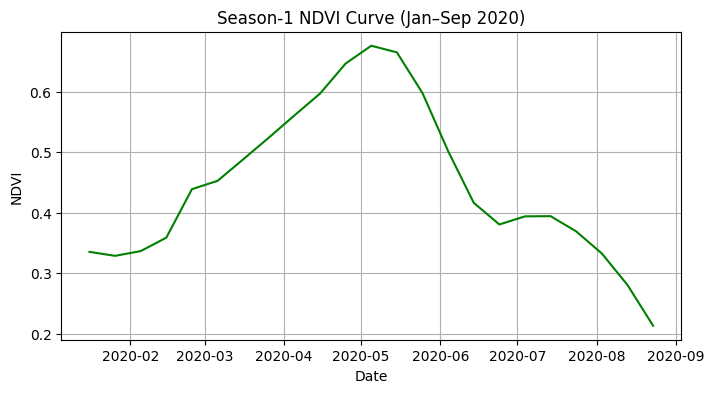

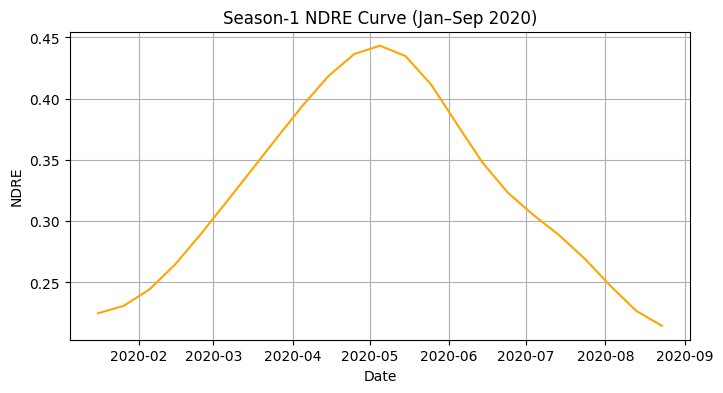

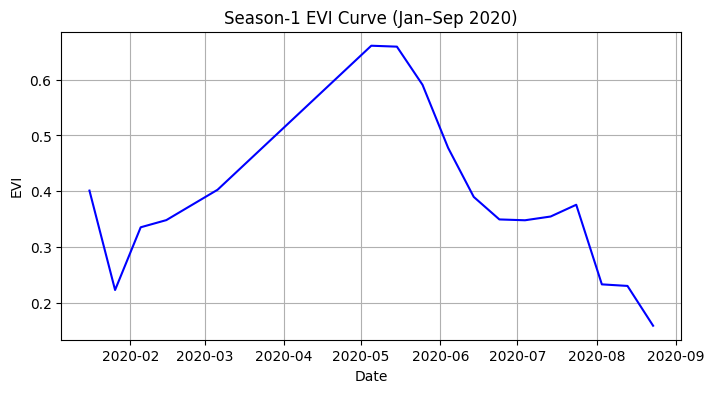

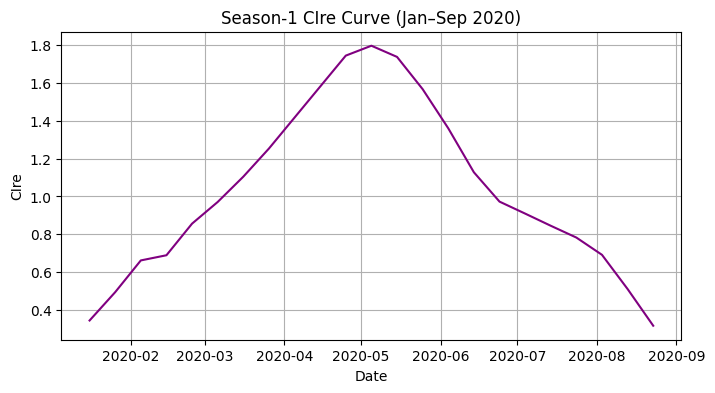

In [24]:
plt.figure(figsize=(8,4))

plt.plot(season1.index, ndvi_smooth, color="green")

plt.title("Season-1 NDVI Curve (Jan–Sep 2020)")
plt.xlabel("Date")
plt.ylabel("NDVI")

plt.grid()

plt.show()

plt.figure(figsize=(8,4))

plt.plot(season1.index, ndre_smooth, color="orange")

plt.title("Season-1 NDRE Curve (Jan–Sep 2020)")
plt.xlabel("Date")
plt.ylabel("NDRE")

plt.grid()

plt.show()

plt.figure(figsize=(8,4))

plt.plot(season1.index, evi_smooth, color="blue")

plt.title("Season-1 EVI Curve (Jan–Sep 2020)")
plt.xlabel("Date")
plt.ylabel("EVI")

plt.grid()

plt.show()

plt.figure(figsize=(8,4))

plt.plot(season1.index, cire_smooth, color="purple")

plt.title("Season-1 CIre Curve (Jan–Sep 2020)")
plt.xlabel("Date")
plt.ylabel("CIre")

plt.grid()

plt.show()

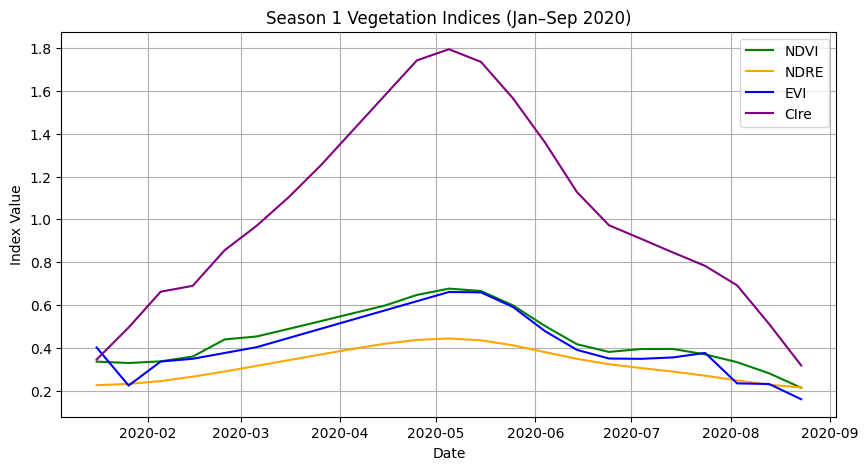

In [23]:
plt.figure(figsize=(10,5))

plt.plot(season1.index, ndvi_smooth, label="NDVI", color="green")

plt.plot(season1.index, ndre_smooth, label="NDRE", color="orange")

plt.plot(season1.index, evi_smooth, label="EVI", color="blue")

plt.plot(season1.index, cire_smooth, label="CIre", color="purple")

plt.title("Season 1 Vegetation Indices (Jan–Sep 2020)")

plt.xlabel("Date")
plt.ylabel("Index Value")

plt.legend()

plt.grid()

plt.show()